In [ ]:
# If you do not use colab. You should install these packages.
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install scikit-learn
# !pip install graphviz

In [6]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [16]:
from model.metrics import MSE, evaluate_linear_regression
from model.gradients import MSE_grad
from model.utils import *
import matplotlib.pyplot as plt

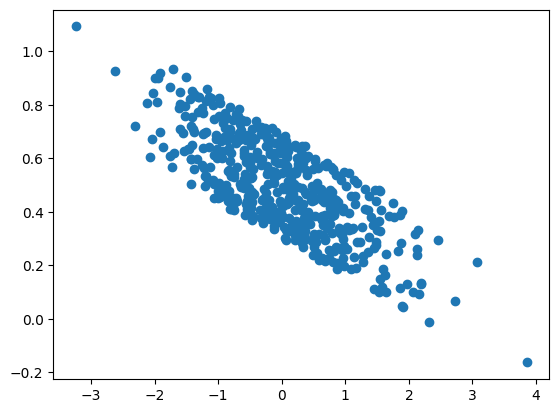

In [ ]:
# Sample Code for generating datasets
seed=42
np.random.seed(seed)
size = 500
dim = 1
noise_bound = 0.2
X,y,W = generate_linear_dataset(size,dim,noise_bound=noise_bound,is_reg=True)
plt.scatter(X[:,1],y)

In [11]:
# Loading data
loaded_data = np.load(f'data/linear_data/linear_data_A.npz')

X = loaded_data['X_data']
y = loaded_data['y_data']
W = loaded_data['W_data']

# Show the size of data
print(f"X size : {X.shape}, y size : {y.shape}")

# Make sure size and dim correct.
size = X.shape[0]
dim = X.shape[1]-1

X size : (1600, 2), y size : (1600,)


50. Training loss: 1.1451587601145723, Val loss:1.1835230479722467
100. Training loss: 0.9503348495853221, Val loss:0.9816866178920054
150. Training loss: 0.7890501237745033, Val loss:0.8146254353070983
200. Training loss: 0.6555305873763618, Val loss:0.6763491589866026
250. Training loss: 0.5449963105448375, Val loss:0.5618992520945488
300. Training loss: 0.45349028193283636, Val loss:0.467171262373702
350. Training loss: 0.37773672901734473, Val loss:0.38876771365113516
400. Training loss: 0.31502383196137185, Val loss:0.3238763358273957
450. Training loss: 0.2631066309126785, Val loss:0.27016926880823205
500. Training loss: 0.22012664984747138, Val loss:0.22571962766322928


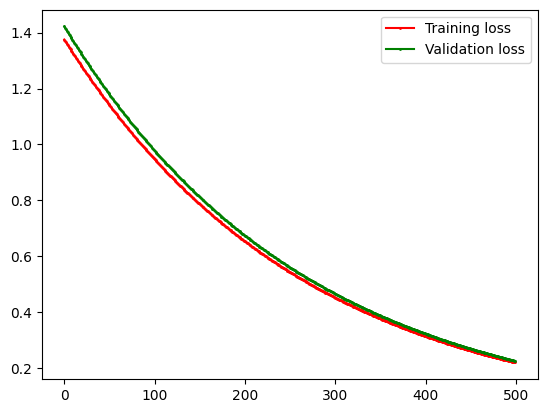

,dim,1
,is_reg,True
,loss_fn,<function MSE...001945470C680>
,grad_fn,<function MSE...0019466DEBB00>
,act_fn,<function Lin...0019466F8F6A0>
,lr,0.1
,reg_type,''
,reg_lambda,0
,n_iteration,50
,val_ratio,0.2
,random_state,None


In [ ]:
# Train the model
from model.linear_model import LinearModel

seed = 42 # do not change the seed
np.random.seed(seed)

# Setting loss function and gradient. 
loss_fn = MSE
grad_fn = MSE_grad

# Split dataset to train dataset and validation dataset
X_train,y_train,X_val,y_val = get_train_val(X,y)

# Setting model and starting training
model = LinearModel(dim,True,loss_fn,grad_fn)
model.fit(X_train,y_train,lr=0.01,n_iteration =500,val_ratio=0.2)

In [14]:
# Get the Prediction
y_val_pred = model.predict(X_val)

In [15]:
# Evaluation 
# Please complete the evaluate_linear_regression in the model/metrics.py by the sklearn package.
evaluate_linear_regression(y_true=y_val,y_pred=y_val_pred,title='Linear Regression Evaluation')

=== Linear Regression Evaluation ===


ValueError: Unknown format code 'f' for object of type 'str'

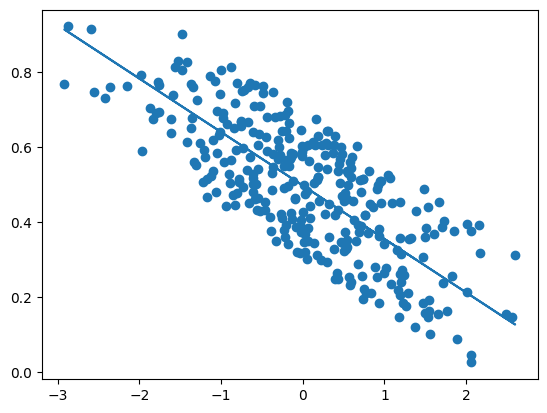

In [ ]:
# Plot
plt.scatter(X_val[:,1],y_val)
plt.plot(X_val[:,1],y_val_pred)
plt.show()